In [1]:
from misas.fastai_model import Fastai2_model

## Load model example image and mask

In [2]:
trainedModel = Fastai2_model('chfc-cmi/cmr-seg-tl', 'cmr_seg_base')

Using cache found in /tank/home/iimog/.cache/torch/hub/chfc-cmi_cmr-seg-tl_master
/tank/home/iimog/projects/cmr-dynamic-radiomics-stability/code/supplement/.venv/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [3]:
import nibabel as nib

In [4]:
im4d = nib.load("data/subject_data/Proband X1/DICOM_WIP_sSA_SENSE_20140309102011_1101.nii.gz").get_fdata()

In [5]:
mask4d = nib.load("data/subject_data/Proband X1/DICOM_WIP_sSA_SENSE_20140309102011_1101_mask.nii.gz").get_fdata()

In [6]:
import matplotlib.pyplot as plt

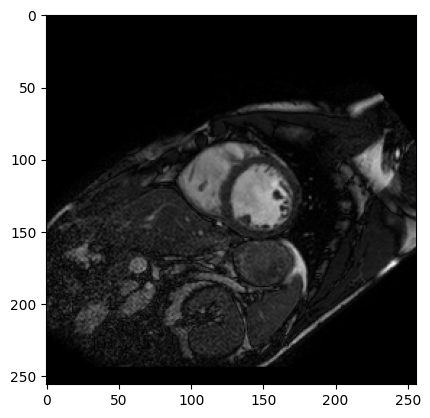

In [7]:
plt.imshow(im4d[:,:,8,0], cmap="gray")

In [8]:
mask4d.shape

(256, 256, 15, 50)

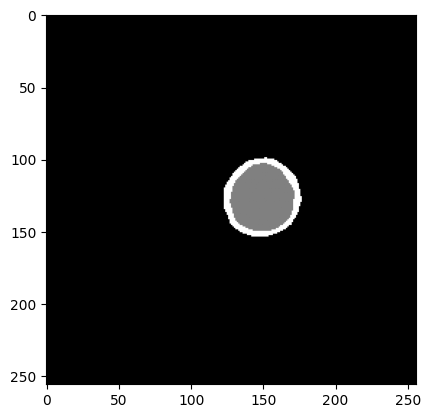

In [9]:
plt.imshow(mask4d[:,:,8,0], cmap="gray")

In [10]:
from PIL import Image
import numpy as np

In [11]:
def prepareImage(img):
    img = ((img-img.min())/(img.max()-img.min())*255).astype(np.uint8)
    img = Image.fromarray(np.array(img))
    return img.convert("RGB")

In [12]:
rgb = prepareImage(im4d[:,:,8,0])
pred = trainedModel.predict(rgb)

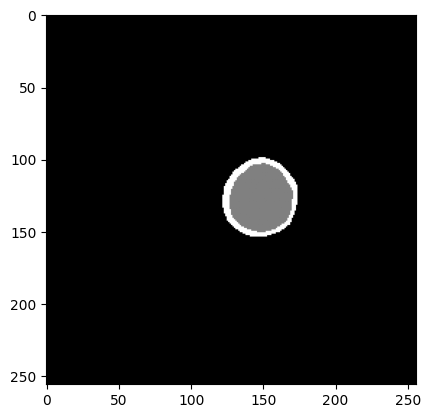

In [13]:
plt.imshow(pred, cmap="gray")

The original prediction was done on DICOM images. Compared to nifti the axes are swapped and partially flipped. Therefore the masks do not align perfectly. But the exact prediction can be reproduced when done on an image with axes as in dicom (see dihedral series below).

### Confirm reproducibility

In [14]:
def img():
    return prepareImage(im4d[:,:,8,0])

In [15]:
def trueMask():
    return Image.fromarray(np.array(mask4d[:,:,8,0].astype(np.uint8)),'L')

In [16]:
from misas.core import plot_series, get_dihedral_series

  0%|          | 0/8 [00:00<?, ?it/s]

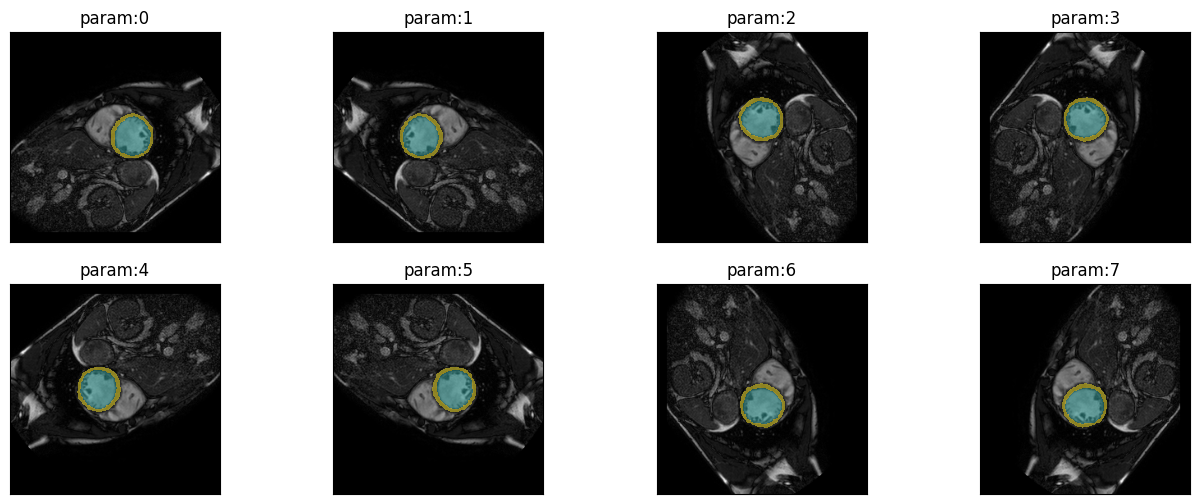

In [17]:
result = get_dihedral_series(img(), trainedModel, truth=trueMask())
plot_series(result, nrow=2)

In [18]:
from misas.core import eval_generic_series, plot_eval_series, eval_dihedral_series

In [19]:
result = eval_dihedral_series(img(), trueMask(), trainedModel)
print(result)
plot_eval_series(result, chart_type="point")

  0%|          | 0/8 [00:00<?, ?it/s]

   k        bg        c1        c2
0  0  0.998917  0.977160  0.837317
1  1  0.999028  0.982759  0.863463
2  2  1.000000  1.000000  1.000000
3  3  0.999620  0.990809  0.941353
4  4  0.998419  0.964033  0.765011
5  5  0.998506  0.966451  0.778932
6  6  0.998640  0.968298  0.794623
7  7  0.998506  0.966154  0.777032


alt.Chart(...)

## Evaluate influence of noise on segmentation

In [20]:
import torchio as tio
import torch

In [21]:
def trueMask():
    return trainedModel.predict(img())

In [22]:
def add_noise(image_data, noise):
    torch.manual_seed(42)
    image_data = np.array(image_data)[:,:,0,None,None]
    file_max = image_data.max()
    std = float(noise) * file_max
    image_data = tio.ScalarImage(tensor=image_data)
    subject = tio.Subject(image=image_data)
    transforms = tio.RandomNoise(std=(std,std))
    transformed_image = transforms(subject)
    return prepareImage(transformed_image.image.tensor[:,:,0,0].numpy())

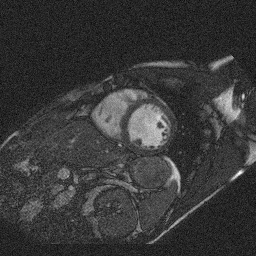

In [23]:
noisy = add_noise(np.array(img()), 0.04)
noisy

In [24]:
from misas.core import get_generic_series

In [25]:
def get_noise_series(image, model, start=0, end=0.1, step=.01, **kwargs):
    return get_generic_series(image,model,add_noise, start=start, end=end, step=step, **kwargs)

  0%|          | 0/10 [00:00<?, ?it/s]

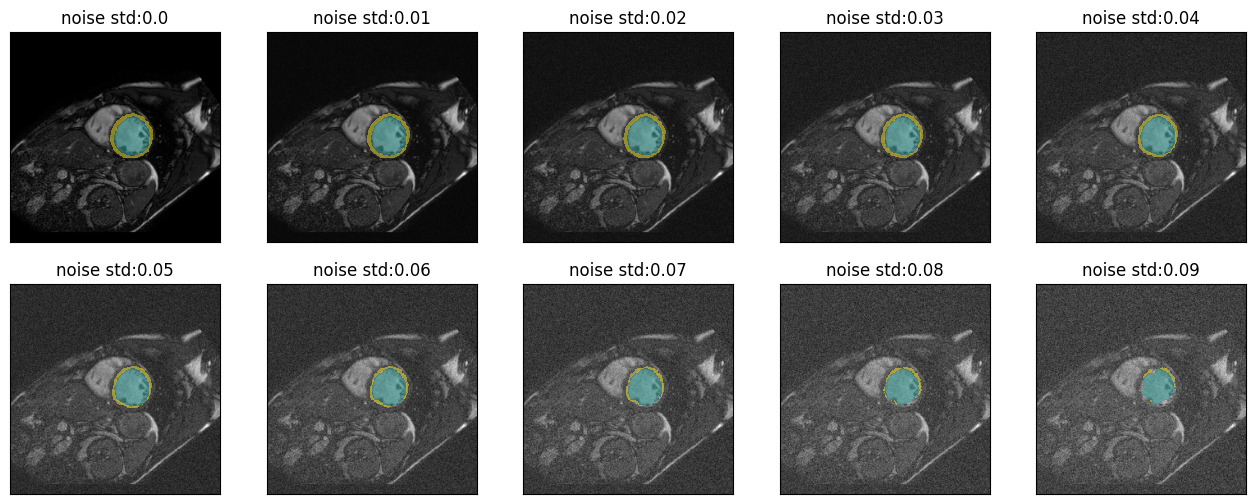

In [30]:
result = get_noise_series(img(), trainedModel)
plot_series(result, nrow=2, param_name="noise std")

In [27]:
result = eval_generic_series(img(), trueMask(), trainedModel, add_noise, start=0, end=0.1, step=0.01, param_name="noise std", mask_transform_function=None, components=["bg","lv","myo"])

  0%|          | 0/10 [00:00<?, ?it/s]

In [28]:
result

,noise std,bg,lv,myo
0,0.00,1.000000,1.000000,1.000000
1,0.01,0.999747,0.994725,0.960130
2,0.02,0.999361,0.987516,0.899083
3,0.03,0.998950,0.983072,0.838932
4,0.04,0.998297,0.977946,0.737132
5,0.05,0.997597,0.966177,0.621752
6,0.06,0.996764,0.950130,0.512768
7,0.07,0.996042,0.936003,0.452586
8,0.08,0.994954,0.913116,0.374269
9,0.09,0.993307,0.869413,0.249671


In [29]:
plot_eval_series(result)

alt.Chart(...)